In [2]:
# If you are using colab, you can mount your google drive and access data from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing
We interpolate then normalize the data. Each is done individually

In [3]:
# Replace with your own files
#!cp "/content/drive/My Drive/ramandata/conor/Train_Inputs.mat" .
#!cp "/content/drive/My Drive/ramandata/conor/Test_Inputs.mat" .

In [4]:
import h5py
import numpy as np

# 1. Insert the correct path to your file on Google Drive
percorso_mat = '/content/drive/MyDrive/Tesi_Raman/Datasets/TROPHY.mat'

# 2. Open the v7.3 .mat file as an HDF5 file
with h5py.File(percorso_mat, 'r') as f:

    # Extract the variables and use .T (Transpose) to get back the original shape (N_spectra, N_points)
    X_raw = np.array(f['Xtrophy']).T
    Y_binary = np.array(f['Ytrophy_binary']).T
    asse_X = np.array(f['asse_X']).T

# 3. Quick check to be sure!
print(f"Shape of the spectra: {X_raw.shape}") # Should be (N_samples, N_points)
print(f"Shape of the labels: {Y_binary.shape}")
print(f"Original X axis goes from {asse_X.min()} to {asse_X.max()}")

Shape of the spectra: (115913, 820)
Shape of the labels: (115913, 1)
Original X axis goes from 648.6803588867188 to 3050.43994140625


In [5]:
# Global parameters for the new wavelength axis
MIN_WAVE = 650
MAX_WAVE = 1750
NUM_PUNTI = 1000

# Creation of the new equally spaced target axis
asse_target = np.linspace(MIN_WAVE, MAX_WAVE, NUM_PUNTI)

print(f"New target axis created: from {MIN_WAVE} to {MAX_WAVE} with {NUM_PUNTI} points.")

New target axis created: from 650 to 1750 with 1000 points.


In [6]:
# This code is no longer needed since the X axis is extracted from TROPHY.mat as asse_X

# def read_axis(filename):
#     """Read the wavelength axis from file."""
#     with open(filename, 'r') as f:
#         wavelengths = np.array([float(line.strip()) for line in f])
#     return wavelengths

# wavelengths = read_axis("/content/drive/My Drive/ramandata/conor/axis.txt")


In [7]:
from scipy import interpolate
from tqdm import tqdm

def interpolate_spectra(spectra_data, old_wavelengths, target_wavelengths):
    # Initialize array for interpolated spectra
    interpolated_spectra = np.zeros((spectra_data.shape[0], len(target_wavelengths)))

    # Interpolate each spectrum
    for i in tqdm(range(spectra_data.shape[0])):
        # Create cubic spline interpolation function
        f = interpolate.CubicSpline(old_wavelengths, spectra_data[i, :])

        # Apply interpolation to target wavelength points
        interpolated_spectra[i, :] = f(target_wavelengths)

    return interpolated_spectra, target_wavelengths


In [8]:
def normalize_raman_spectra(spectra):
    # Create output array
    normalized = np.zeros_like(spectra)

    # Normalize each spectrum individually
    for i in tqdm(range(spectra.shape[0])):
        spectrum = spectra[i, :]
        min_val = np.min(spectrum)
        max_val = np.max(spectrum)

        # Min-max normalization to [0,1] range
        normalized[i, :] = (spectrum - min_val) / (max_val - min_val)

    return normalized

In [9]:
# Adapt the X axis to 1D format
asse_X_flat = asse_X.flatten()

interpolated_spectra, new_wavelengths = interpolate_spectra(
    X_raw,
    asse_X_flat,
    target_wavelengths=asse_target
)


100%|██████████| 115913/115913 [00:54<00:00, 2113.26it/s]


In [10]:
normalized_spectra = normalize_raman_spectra(interpolated_spectra)
normalized_spectra.shape

100%|██████████| 115913/115913 [00:03<00:00, 33480.94it/s]


(115913, 1000)

In [11]:
import os

# Requested save path
save_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max'
os.makedirs(save_dir, exist_ok=True) # Create the folder if it doesn't exist

save_path = os.path.join(save_dir, 'trophy_normalized_spectra_FingerPrint.npz')

# Save the normalized spectra, the new x-axis and the labels in float32 to save memory
np.savez(save_path,
          spectra=normalized_spectra.astype(np.float32),
          wavelengths=new_wavelengths.astype(np.float32),
          labels=Y_binary.astype(np.float32))

print(f"Data successfully saved in: {save_path}")

Data successfully saved in: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/trophy_normalized_spectra_FingerPrint.npz


In [12]:
# Verify the saved data
print("--- VERIFYING SAVED DATA ---")
loaded_data = np.load(save_path)
loaded_spectra = loaded_data['spectra']
loaded_wavelengths = loaded_data['wavelengths']

print(f"Shape of saved spectra: {loaded_spectra.shape}")
print(f"Wavelength axis length: {len(loaded_wavelengths)}")
print(f"Min wavelength: {loaded_wavelengths.min():.2f}")
print(f"Max wavelength: {loaded_wavelengths.max():.2f}")

if len(loaded_wavelengths) == 1000 and round(loaded_wavelengths.min()) == 650 and round(loaded_wavelengths.max()) == 1750:
    print("\n✅ SUCCESS: The axis is correctly cut to 1000 points between 650 and 1750!")
else:
    print("\n❌ ERROR: The axis is not what was expected.")


--- VERIFYING SAVED DATA ---
Shape of saved spectra: (115913, 1000)
Wavelength axis length: 1000
Min wavelength: 650.00
Max wavelength: 1750.00

✅ SUCCESS: The axis is correctly cut to 1000 points between 650 and 1750!


# Plot Comparison
These plots are used in Several figures throughout the RamanFoundation paper

In [13]:
import matplotlib.pyplot as plt
plt.style.use('default')

FONTSIZE_AXIS = 15
FONTSIZE_TITLE=15

In [14]:
# Helpers
def get_spectra_from_range(spectra, wavelengths, wavelength_range):
  # Find indices of wavelengths within the range
  indices = np.where((wavelengths >= wavelength_range[0]) &
                     (wavelengths <= wavelength_range[1]))[0]

  # Extract the corresponding spectra
  extracted_spectra = spectra[indices]
  extracted_wavelengths = wavelengths[indices]

  return extracted_wavelengths, extracted_spectra

This plot is used to provide an example of interpolation in Figure 3

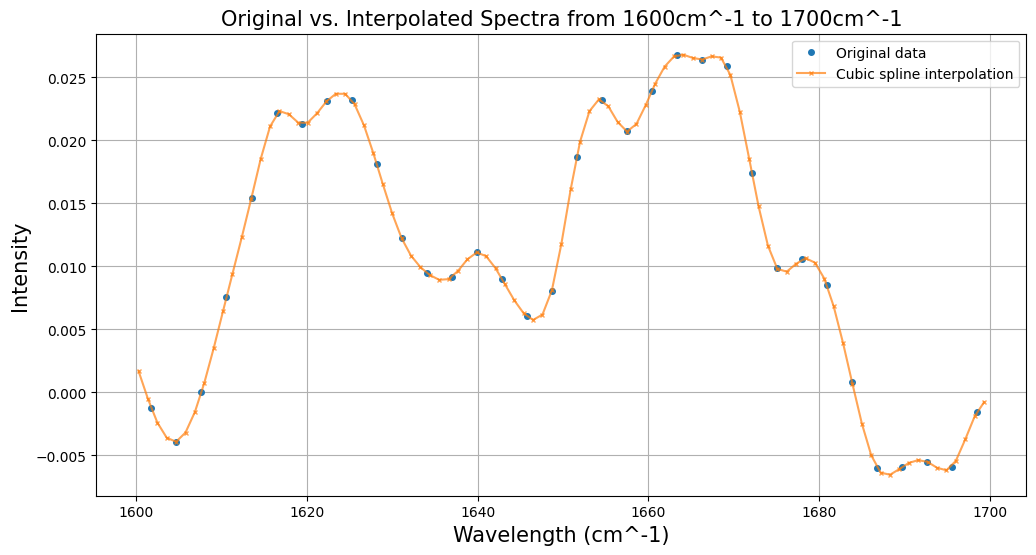

In [15]:
wavelength_range = (1600, 1700) # Modified for a larger range
sample_idx = 0

training_sample = X_raw[sample_idx]
interpolated_sample = interpolated_spectra[sample_idx]

wavelengths_original, spectra_original = get_spectra_from_range(training_sample, asse_X_flat, wavelength_range)
wavelengths_interpolated, spectra_interpolated = get_spectra_from_range(interpolated_sample, new_wavelengths, wavelength_range)

plt.figure(figsize=(12,6))
plt.plot(wavelengths_original, spectra_original,
        'o', label='Original data', markersize=4) # Reduced markersize to better visualize the numerous points
plt.plot(wavelengths_interpolated, spectra_interpolated,
          'x-', label='Cubic spline interpolation', alpha=0.7, markersize=3) # Restored the 'x' marker for interpolated points

plt.xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
plt.ylabel('Intensity', fontsize=FONTSIZE_AXIS)
plt.title(f'Original vs. Interpolated Spectra from {wavelength_range[0]}cm^-1 to {wavelength_range[1]}cm^-1', fontsize=FONTSIZE_TITLE)
plt.legend()
plt.grid(True)
plt.show()

This plot is used to show normalization in Figure 3

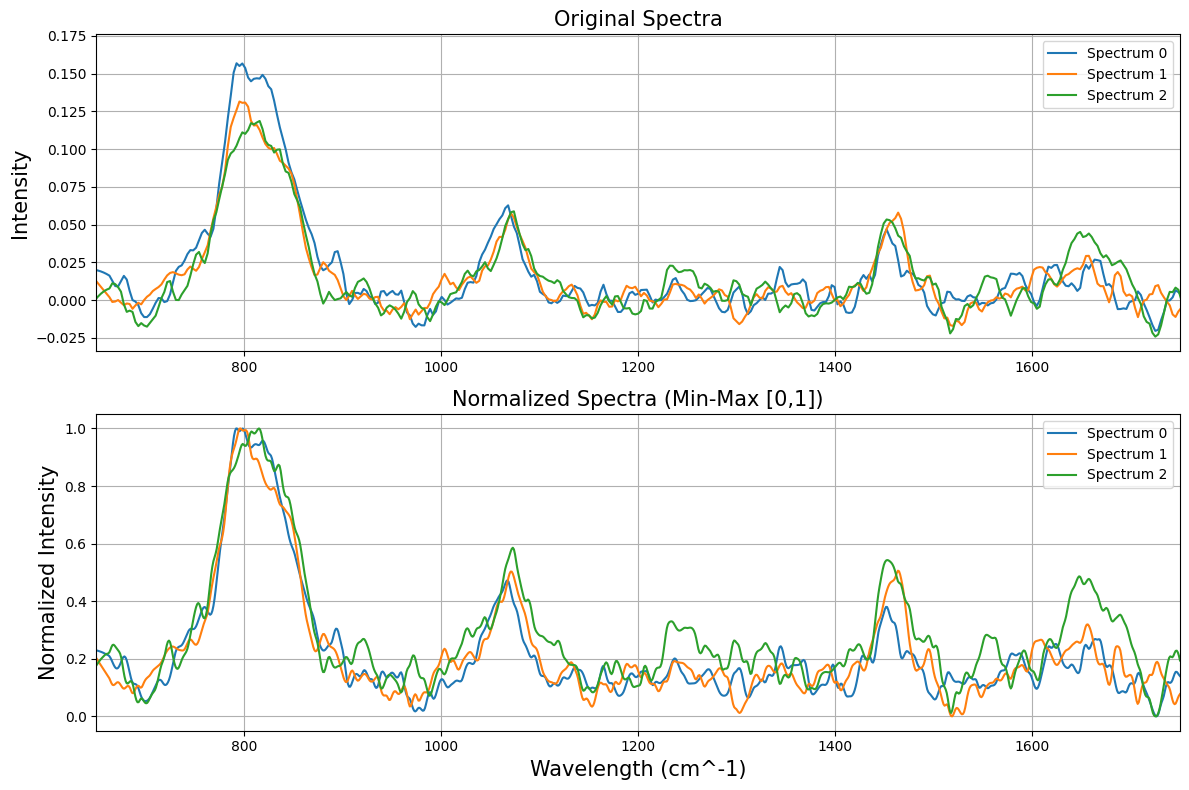

In [16]:
def plot_normalization_comparison(original_spectra, normalized_spectra, sample_indices=[0,1,2]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot original spectra
    for idx in sample_indices:
        ax1.plot(asse_X_flat, original_spectra[idx], label=f'Spectrum {idx}')
    ax1.set_title('Original Spectra', fontsize=FONTSIZE_TITLE)
    # ax1.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax1.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
    ax1.set_xlim([MIN_WAVE, MAX_WAVE]) # Limit the x-axis to the new range
    ax1.legend()
    ax1.grid(True)

    # Plot normalized spectra
    for idx in sample_indices:
        ax2.plot(new_wavelengths, normalized_spectra[idx], label=f'Spectrum {idx}')
    ax2.set_title('Normalized Spectra (Min-Max [0,1])', fontsize=FONTSIZE_TITLE)
    ax2.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax2.set_ylabel('Normalized Intensity', fontsize=FONTSIZE_AXIS)
    ax2.set_xlim([MIN_WAVE, MAX_WAVE]) # Limit the x-axis to the new range
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


# Plot comparison
plot_normalization_comparison(X_raw, normalized_spectra)

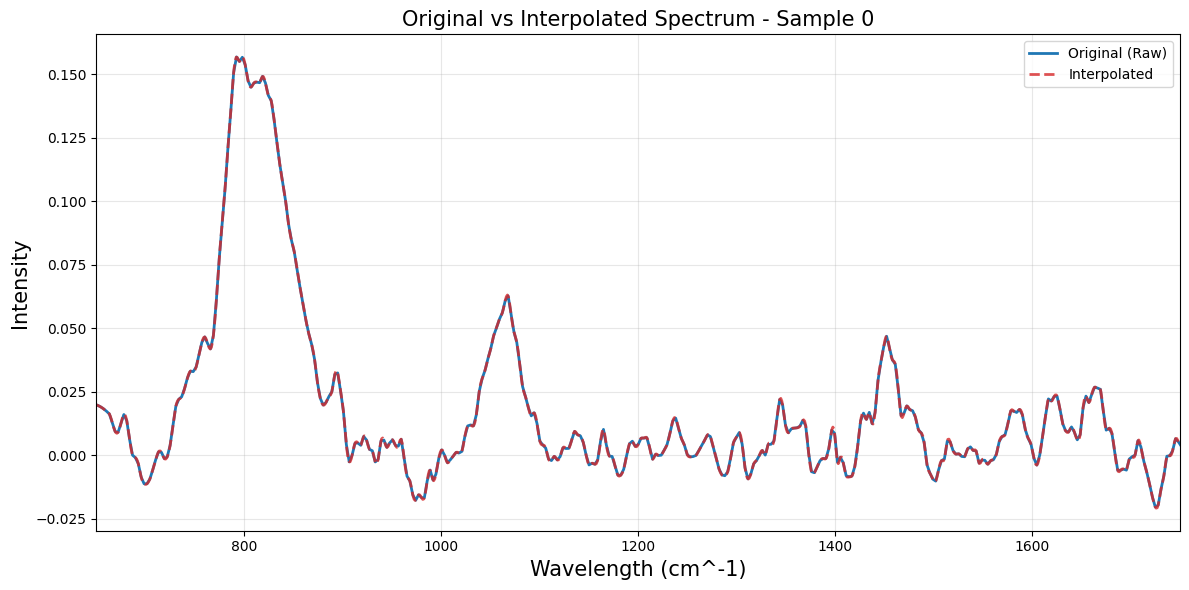

In [17]:
# Overlay of original and interpolated spectra to verify shape preservation
sample_idx = 0

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Original Spectrum
ax.plot(asse_X_flat, X_raw[sample_idx], color='tab:blue', label='Original (Raw)', linewidth=2)

# Plot Interpolated Spectrum
ax.plot(new_wavelengths, interpolated_spectra[sample_idx], color='tab:red',
         linestyle='--', alpha=0.8, label='Interpolated', linewidth=2)

# Formatting the plot
ax.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
ax.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
ax.set_xlim([MIN_WAVE, MAX_WAVE])
ax.set_title(f'Original vs Interpolated Spectrum - Sample {sample_idx}', fontsize=FONTSIZE_TITLE)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

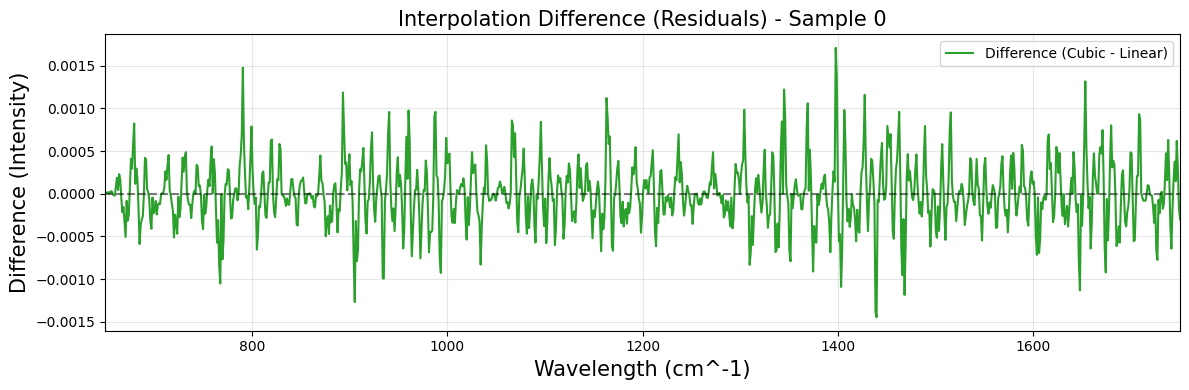

In [18]:
# Calculate and plot the difference between the interpolated spectrum and the original data
from scipy.interpolate import interp1d

sample_idx = 0

# 1. Create a linear interpolation of the original data on the new wavelengths as a baseline
linear_baseline = interp1d(asse_X_flat, X_raw[sample_idx], kind='linear')(new_wavelengths)

# 2. Calculate the difference (Cubic Spline Interpolation vs Linear Baseline)
difference = interpolated_spectra[sample_idx] - linear_baseline

# 3. Plot the difference
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(new_wavelengths, difference, color='tab:green', label='Difference (Cubic - Linear)', linewidth=1.5)

# Formatting the plot
ax.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
ax.set_ylabel('Difference (Intensity)', fontsize=FONTSIZE_AXIS)
ax.set_xlim([MIN_WAVE, MAX_WAVE])
ax.set_title(f'Interpolation Difference (Residuals) - Sample {sample_idx}', fontsize=FONTSIZE_TITLE)
ax.axhline(0, color='black', linestyle='--', alpha=0.5) # Add a zero line for reference
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [19]:
import numpy as np

# Calculate the simple mean error (can be close to 0 if positive and negative errors cancel out)
mean_error = np.mean(difference)

# Calculate Mean Absolute Error (MAE) - better for understanding average magnitude of error
mae = np.mean(np.abs(difference))

# Calculate Root Mean Square Error (RMSE) - penalizes larger differences more
rmse = np.sqrt(np.mean(difference**2))

print(f"--- Error Metrics for Sample {sample_idx} ---")
print(f"Simple Mean Difference: {mean_error:.6e}")
print(f"Mean Absolute Error (MAE): {mae:.6e}")
print(f"Root Mean Square Error (RMSE): {rmse:.6e}")

--- Error Metrics for Sample 0 ---
Simple Mean Difference: 1.593964e-06
Mean Absolute Error (MAE): 2.627138e-04
Root Mean Square Error (RMSE): 3.667384e-04
